# v2 exploration: does the stable rank predict memory beyond human dMRI connectomes?

**Status: exploratory, not part of the manuscript.** It tests whether the relation found in 3,901 human
connectomes (memory capacity grows with the log of the stable rank, `paper/`) carries over to
mesoscale connectomes of other species, including *Drosophila*.

Data: the connectomes packaged with **bio2art** (Goulas, Damicelli & Hilgetag, *Neural Networks* 142, 608–618, 2021;
https://github.com/AlGoulas/bio2art). Cite the original dataset of each network if used
(listed in the bio2art README; fly: Chiang et al., *Curr. Biol.* 21, 1–11, 2011).

Method: closed-form memory (SI Note 2) with the manuscript's noise floor, spectral radius 0.99, 20 delays,
averaged over 10 random input vectors. No simulation yet. Most of these networks are **directed**, so we
compute both the network as given and its symmetrised version (the human dMRI connectomes are symmetric).

Caveats: different sizes (19–57 nodes, vs 90), different weight definitions (tract tracing, streamlines,
light microscopy), one network per species. Six points are an illustration, not a test.

In [1]:
import sys, urllib.request
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "paper" else Path.cwd()
DATA = Path.home() / ".cache" / "bio2art"          # downloaded third-party data stay outside the repo
DATA.mkdir(parents=True, exist_ok=True)
URL = "https://raw.githubusercontent.com/AlGoulas/bio2art/master/bio2art/connectomes/C_{}.npy"
NETS = {"Drosophila": "fly", "Mouse_Gamanut_Normalized": "mouse (Gamanut)", "Mouse_Ypma_Oh": "mouse (Oh)",
        "Human_Betzel_Normalized": "human (Betzel)", "Macaque_Normalized": "macaque", "Marmoset_Normalized": "marmoset"}
for n in NETS:
    f = DATA / f"C_{n}.npy"
    if not f.exists():
        urllib.request.urlretrieve(URL.format(n), f)
mats = {n: np.load(DATA / f"C_{n}.npy", allow_pickle=False).astype(float) for n in NETS}
{NETS[n]: m.shape for n, m in mats.items()}

{'fly': (49, 49),
 'mouse (Gamanut)': (19, 19),
 'mouse (Oh)': (56, 56),
 'human (Betzel)': (57, 57),
 'macaque': (29, 29),
 'marmoset': (55, 55)}

In [2]:
S2U, ETA0, TAU = 1 / 3, 1e-6 / 6300, 20          # as in paper/paper_analysis.py

def input_gramian(W, w):
    C, A = S2U * np.outer(w, w), W.copy()
    for _ in range(16):
        C = C + A @ C @ A.T
        A = A @ A
    return 0.5 * (C + C.T)

def closed_form_mc(W, w, eta=ETA0):
    """m(tau) summed over tau = 1..TAU (SI Eq. S8) and the effective rank (SI Eq. S10). Valid for directed W."""
    C = input_gramian(W, w)
    c, U = np.linalg.eigh(C); c = np.clip(c, 0, None)
    g, mc = S2U * w, 0.0
    for _ in range(TAU):
        g = W @ g
        p = (U.T @ g) ** 2
        mc += (p / (c + eta)).sum() ** 2 / (S2U * (p * c / (c + eta) ** 2).sum())
    return mc, (c / (c + eta)).sum()

rows = []
for n, A in mats.items():
    A = A.copy(); np.fill_diagonal(A, 0)
    for kind, M in [("as given", A), ("symmetrised", 0.5 * (A + A.T))]:
        rho = np.abs(np.linalg.eigvals(M)).max()
        W = 0.99 * M / rho
        res = np.array([closed_form_mc(W, np.random.default_rng(s).uniform(-1, 1, len(M))) for s in range(10)])
        rows.append(dict(network=NETS[n], kind=kind, N=len(M), directed=not np.allclose(M, M.T),
                         density=(M != 0).mean(), stable_rank=(M ** 2).sum() / rho ** 2,
                         non_normality=np.linalg.norm(M, 2) / rho, MC=res[:, 0].mean(), eff_rank=res[:, 1].mean()))
T = pd.DataFrame(rows)
T.round(3)

,network,kind,N,directed,density,stable_rank,non_normality,MC,eff_rank
0,fly,as given,49,True,0.812,2.337,1.054,6.930,8.168
1,fly,symmetrised,49,False,0.877,1.912,1.000,6.911,8.207
2,mouse (Gamanut),as given,19,True,0.911,4.907,1.536,8.102,9.758
3,mouse (Gamanut),symmetrised,19,False,0.936,2.662,1.000,7.926,9.471
4,mouse (Oh),as given,56,True,0.630,2.854,1.153,7.348,8.756
5,mouse (Oh),symmetrised,56,False,0.792,2.074,1.000,7.401,8.842
6,human (Betzel),as given,57,False,0.195,4.131,1.000,9.087,10.602
7,human (Betzel),symmetrised,57,False,0.195,4.131,1.000,9.087,10.602
8,macaque,as given,29,True,0.637,5.452,1.071,10.082,11.722
9,macaque,symmetrised,29,False,0.766,4.444,1.000,9.921,11.553


In [3]:
# human dMRI line: closed-form MC against log stable rank (paper/data/subject_v2.csv)
H = pd.read_csv(REPO / "paper" / "data" / "subject_v2.csv")
p = np.polyfit(np.log(H["stable_rank"]), H["MC_theory_py"], 1)
T["MC_from_human_line"] = np.polyval(p, np.log(T["stable_rank"]))
T["residual"] = T["MC"] - T["MC_from_human_line"]
sym = T[T["kind"] == "symmetrised"]
print(f"human line: MC = {p[1]:.2f} + {p[0]:.2f} log r_s   (3,901 connectomes, r_s from {H.stable_rank.min():.1f} to {H.stable_rank.max():.1f})")
print(f"symmetrised networks: r(log r_s, MC) = {np.corrcoef(np.log(sym.stable_rank), sym.MC)[0, 1]:.3f}")
T[["network", "kind", "N", "stable_rank", "MC", "MC_from_human_line", "residual"]].round(2)

human line: MC = 3.36 + 4.21 log r_s   (3,901 connectomes, r_s from 2.7 to 9.8)
symmetrised networks: r(log r_s, MC) = 0.989


,network,kind,N,stable_rank,MC,MC_from_human_line,residual
0,fly,as given,49,2.34,6.93,6.93,0.00
1,fly,symmetrised,49,1.91,6.91,6.08,0.83
2,mouse (Gamanut),as given,19,4.91,8.10,10.05,-1.95
3,mouse (Gamanut),symmetrised,19,2.66,7.93,7.47,0.45
4,mouse (Oh),as given,56,2.85,7.35,7.77,-0.42
5,mouse (Oh),symmetrised,56,2.07,7.40,6.43,0.98
6,human (Betzel),as given,57,4.13,9.09,9.32,-0.24
7,human (Betzel),symmetrised,57,4.13,9.09,9.32,-0.24
8,macaque,as given,29,5.45,10.08,10.49,-0.41
9,macaque,symmetrised,29,4.44,9.92,9.63,0.29


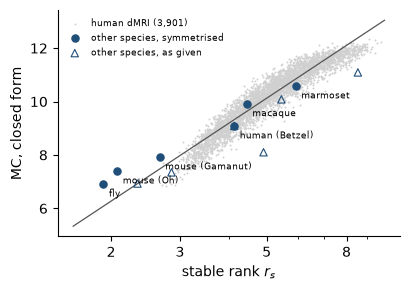

In [4]:
fig, ax = plt.subplots(figsize=(4.2, 3.0))
ax.scatter(H["stable_rank"], H["MC_theory_py"], s=2, color="#d0d0d0", lw=0, rasterized=True, label="human dMRI (3,901)")
x = np.linspace(1.6, 10, 50); ax.plot(x, np.polyval(p, np.log(x)), color="#555555", lw=0.9)
for kind, mk in [("symmetrised", "o"), ("as given", "^")]:
    g = T[T["kind"] == kind]
    ax.scatter(g["stable_rank"], g["MC"], marker=mk, s=28, facecolor="#1f4e79" if mk == "o" else "none",
               edgecolor="#1f4e79", lw=0.8, zorder=3, label=f"other species, {kind}")
for _, r in T[T["kind"] == "symmetrised"].iterrows():
    ax.annotate(r["network"], (r["stable_rank"], r["MC"]), xytext=(4, -9), textcoords="offset points", fontsize=6.5)
ax.set_xscale("log"); ax.set_xticks([2, 3, 5, 8]); ax.set_xticklabels(["2", "3", "5", "8"])
from matplotlib.ticker import NullFormatter; ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xlabel("stable rank $r_s$"); ax.set_ylabel("MC, closed form")
ax.spines[["top", "right"]].set_visible(False); ax.legend(frameon=False, fontsize=6.5, loc="upper left")
fig.tight_layout(); fig.savefig(REPO / "paper" / "figures" / "explore_cross_species.png", dpi=200)
plt.show()

## Reading (first pass, to be discussed)

* **Symmetrised networks.** The six networks are ordered by stable rank as their memory is ordered
  ($r(\log r_s,\mathrm{MC})=0.99$ across species). The four inside or near the human range of $r_s$
  (human Betzel, macaque, marmoset, mouse Gamanut) lie within 0.5 MC units of the human line; the fly and the
  Oh mouse network lie below the human range ($r_s\approx2$) and about one unit above the extrapolated line.
* **Directed networks.** Directionality changes memory little here (these mesoscale networks are largely
  reciprocal), but it inflates $\lVert W\rVert_F^2/\rho^2$, so the stable rank computed on the directed matrix
  over-predicts memory (residuals down to $-2$). For directed networks the predictor has to be adapted
  (symmetric part, or singular values), and non-normal amplification enters (manuscript, SI Note 5).
* **What it would take to use this:** (i) simulate the tanh reservoirs (`ESNcpp/esn_mc` accepts any size through
  `reservoir_size`); (ii) an ensemble per species rather than one network (e.g. neuron-level fly connectomes,
  FlyWire or hemibrain, subsampled into many subnetworks, which also brings signs); (iii) a size correction,
  since memory is bounded by $N$.
* **Decision for the manuscript:** at most one SI figure and one sentence in the Discussion ("the relation extends
  to the symmetrised mesoscale connectomes of five other species"), only after (i). A full cross-species analysis,
  with directed and signed neuron-level connectomes, is a separate paper.